In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

## Clustering by DEGs from tumor deconvoluted expression

In [2]:
tumor_expression_deconvoluted=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/RNA_Expression_for_Analysis/tumor_gene_expression_data_new_batch_merged_1903.csv")
significant_genes_limma=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Results/csvs/Significant_DEGs_HighP_vs_LowP_Tumor.csv")

In [3]:

tumor_expression_transposed=tumor_expression_deconvoluted.T

# Make the first row the column names
tumor_expression_transposed.columns = tumor_expression_transposed.iloc[0]  # set first row as header
tumor_expression_transposed = tumor_expression_transposed[1:]  # drop the first row now used as header

# Reset the index if needed (optional)
tumor_expression_transposed = tumor_expression_transposed.reset_index()

# Rename 'Unnamed: 0' column to 'dcc_filename_1'
tumor_expression_transposed = tumor_expression_transposed.rename(columns={"index": "dcc_filename_1"})


proliferative_aois=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Data/Nika_Masters_thesis_main_data/proliferative_aois.csv")

proliferative_aois.head()



,Unnamed: 0,dcc_filename_1,Tumor_total_count,Tumor_Ki67_count,Tumor_Ki67_pRb_count,Tumor_PH3_count,Ki67_prop,Ki67_pRb_prop,PH3_prop,Ki67_pRb_niche_count,Ki67_pRb_niche_prop,AOI_category
0,1,DSP-1001660016604-A-A03.dcc,261,9,76,0,0.034483,0.291188,0.0,85,0.325670,High P / High C
1,2,DSP-1001660016604-A-A05.dcc,296,5,26,0,0.016892,0.087838,0.0,31,0.104730,Low P / High C
2,3,DSP-1001660016604-A-A07.dcc,154,6,31,0,0.038961,0.201299,0.0,37,0.240260,Low P / High C
3,4,DSP-1001660016604-A-A09.dcc,161,2,82,0,0.012422,0.509317,0.0,84,0.521739,High P / High C
4,5,DSP-1001660016604-A-A10.dcc,206,22,104,0,0.106796,0.504854,0.0,126,0.611650,High P / High C


In [4]:

merged_df = pd.merge(tumor_expression_transposed, proliferative_aois, on="dcc_filename_1")


gene_list = significant_genes_limma["Gene"].to_list()

/opt/anaconda3/envs/scimap/lib/python3.10/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/scimap/lib/python3.10/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


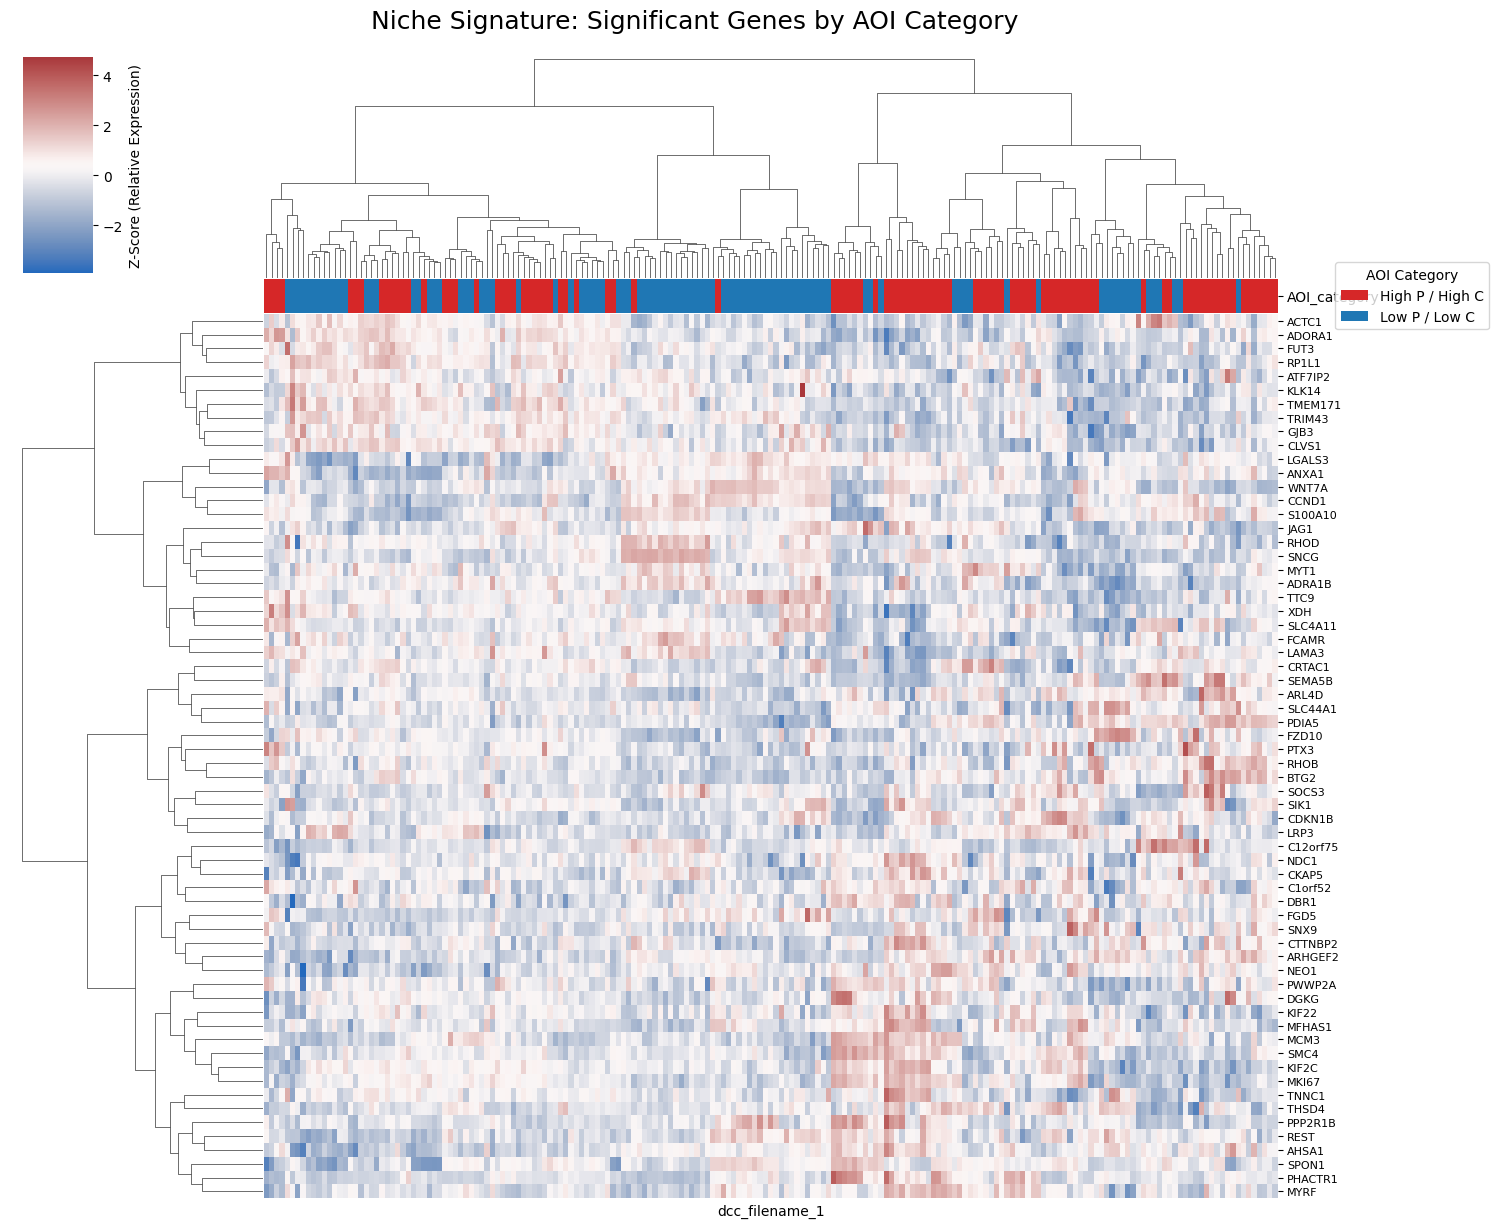

In [5]:

merged_df = merged_df.sort_values('AOI_category')



target_categories = ['High P / High C', 'Low P / Low C']
merged_df_filtered = merged_df[merged_df['AOI_category'].isin(target_categories)].copy()
# 2. Create the matrix and Transpose
# Rows = Genes, Columns = Samples
matrix_transposed = merged_df_filtered.set_index('dcc_filename_1')[gene_list].apply(pd.to_numeric).T

# 3. Create the color map 
# Match the column name exactly to your dataframe ('AOI_category')
unique_categories = merged_df_filtered['AOI_category'].unique()
colors = ["#d62728", "#1f77b4"] # Red for High, Blue for Low
lut = dict(zip(unique_categories, colors))

# Map the colors to the columns
col_colors = merged_df_filtered.set_index('dcc_filename_1')['AOI_category'].map(lut)

# 4. Generate the Clustermap
g = sns.clustermap(matrix_transposed, 
                   z_score=0,                # Standardize expression per gene
                   cmap="vlag",              # Classic diverging Blue-White-Red
                   col_colors=col_colors,    # Category bar at the top
                   col_cluster=True,         # Group similar samples together
                   row_cluster=True,         # Group similar genes together
                   method='ward',            # 'ward' often gives tighter clusters than 'average'
                   figsize=(14, 12), 
                   xticklabels=False,        
                   yticklabels=True,         
                   cbar_kws={'label': 'Z-Score (Relative Expression)'})

# 5. Add the Legend manually (Cleaner approach)
legend_elements = [Patch(facecolor=color, label=label) for label, color in lut.items()]
g.ax_col_colors.legend(handles=legend_elements, title="AOI Category",
                       loc='center left', bbox_to_anchor=(1.05, 0.5))

# 6. Final visual tweaks
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=8) # Shrink gene font if list is long
g.fig.suptitle('Niche Signature: Significant Genes by AOI Category', y=1.02, fontsize=18)

plt.show()

## Clustering by DEG from raw expression

In [2]:
raw_expression_deconvoluted=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/RNA_Expression_for_Analysis/batch123_gene_expression_not_deconvoluted_harmony_batch_corr_deseq2_vst_3003.csv")
significant_genes_limma=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Results/csvs/Significant_DEGs_HighP_vs_LowP_Bulk.csv")

In [3]:

raw_expression_transposed=raw_expression_deconvoluted.T

# Make the first row the column names
raw_expression_transposed.columns = raw_expression_transposed.iloc[0]  # set first row as header
raw_expression_transposed = raw_expression_transposed[1:]  # drop the first row now used as header

# Reset the index if needed (optional)
raw_expression_transposed = raw_expression_transposed.reset_index()

# Rename 'Unnamed: 0' column to 'dcc_filename_1'
raw_expression_transposed = raw_expression_transposed.rename(columns={"index": "dcc_filename_1"})


proliferative_aois=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Data/Nika_Masters_thesis_main_data/proliferative_aois.csv")


In [4]:
metadata=pd.read_csv("/Volumes/h30492/farkkilab2/9_EyeMT/Data/geomx/batch123/metadata/dcc_metadata_batch123_cleaned.csv")
metadata = metadata.rename(columns={'dcc_filename': 'dcc_filename_1'})
merged_df = pd.merge(raw_expression_transposed, proliferative_aois, on="dcc_filename_1")
merged_metadata=pd.merge(proliferative_aois,metadata,on='dcc_filename_1')

/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/scimap_sep17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


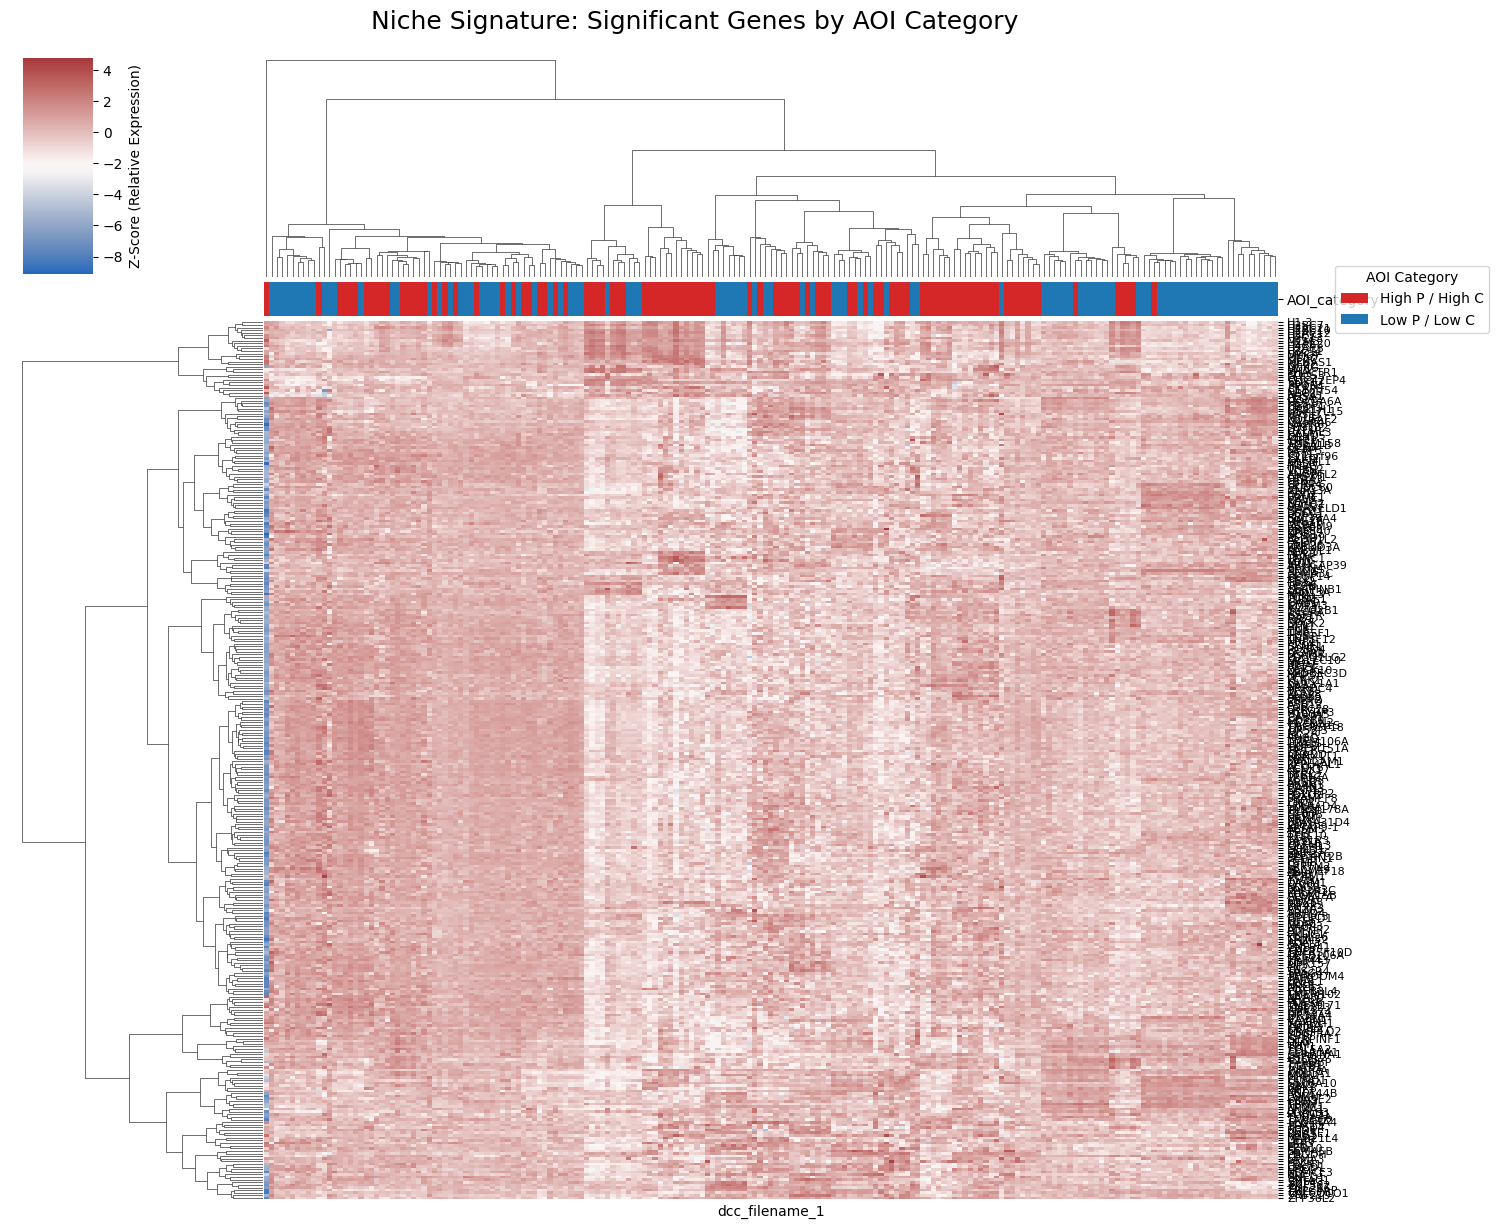

In [7]:

gene_list = significant_genes_limma["Gene"].to_list()

merged_df = merged_df.sort_values('AOI_category')



target_categories = ['High P / High C', 'Low P / Low C']
merged_df_filtered = merged_df[merged_df['AOI_category'].isin(target_categories)].copy()
# 2. Create the matrix and Transpose

matrix_transposed = merged_df_filtered.set_index('dcc_filename_1')[gene_list].apply(pd.to_numeric).T
# 3. Create the color map 
# Match the column name exactly to your dataframe ('AOI_category')
unique_categories = merged_df_filtered['AOI_category'].unique()
colors = ["#d62728", "#1f77b4"] # Red for High, Blue for Low
lut = dict(zip(unique_categories, colors))

# Map the colors to the columns
col_colors = merged_df_filtered.set_index('dcc_filename_1')['AOI_category'].map(lut)

# 4. Generate the Clustermap
g = sns.clustermap(matrix_transposed, 
                   z_score=0,                # Standardize expression per gene
                   cmap="vlag",              # Classic diverging Blue-White-Red
                   col_colors=col_colors,    # Category bar at the top
                   col_cluster=True,         # Group similar samples together
                   row_cluster=True,         # Group similar genes together
                   method='ward',            # 'ward' often gives tighter clusters than 'average'
                   figsize=(14, 12), 
                   xticklabels=False,        
                   yticklabels=True,         
                   cbar_kws={'label': 'Z-Score (Relative Expression)'})

# 5. Add the Legend manually (Cleaner approach)
legend_elements = [Patch(facecolor=color, label=label) for label, color in lut.items()]
g.ax_col_colors.legend(handles=legend_elements, title="AOI Category",
                       loc='center left', bbox_to_anchor=(1.05, 0.5))

# 6. Final visual tweaks
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=8) # Shrink gene font if list is long
g.fig.suptitle('Niche Signature: Significant Genes by AOI Category', y=1.02, fontsize=18)

plt.show()

## Proliferative Signature in the Niches

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3503/3904586098.py:122: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


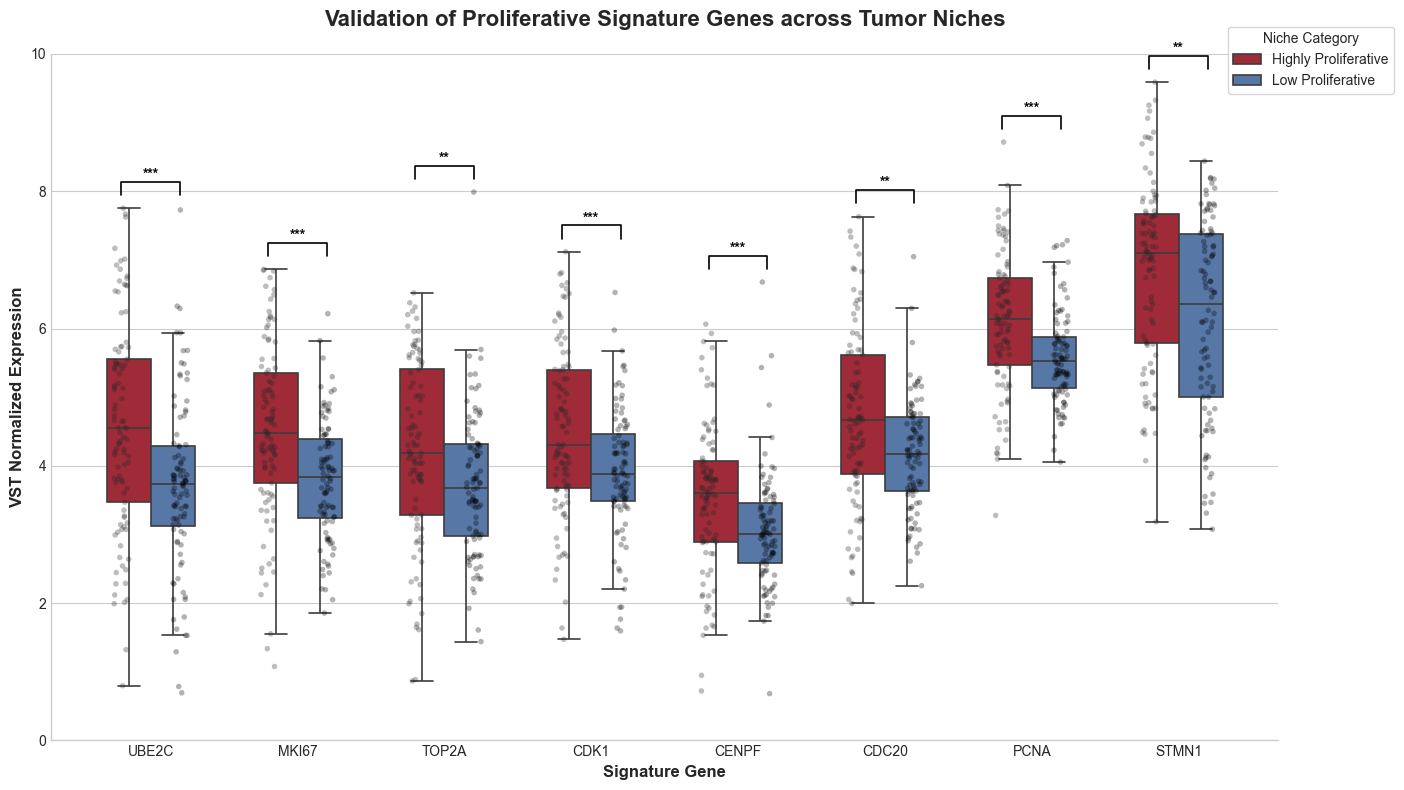

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu # <--- ADDED IMPORT

# ---------------------------------------------------------
# 1. DATA PREPARATION
# ---------------------------------------------------------
# Define the specific genes shown in the plot
genes_to_plot = ['UBE2C', 'MKI67', 'TOP2A', 'CDK1', 'CENPF', 'CDC20', 'PCNA', 'STMN1']

# Filter the dataframe for the two target categories
target_cats = ['High P / High C', 'Low P / Low C']
df_filtered = merged_df[merged_df['AOI_category'].isin(target_cats)].copy()

# Rename the categories to match the plot legend
df_filtered['Niche Category'] = df_filtered['AOI_category'].map({
    'High P / High C': 'Highly Proliferative',
    'Low P / Low C': 'Low Proliferative'
})

# Safety Check: Ensure the genes actually exist in the dataframe to avoid KeyErrors
available_genes = [g for g in genes_to_plot if g in df_filtered.columns]
if len(available_genes) < len(genes_to_plot):
    print(f"Warning: Missing genes in dataframe. Only plotting: {available_genes}")

# Ensure the gene columns are numeric
for gene in available_genes:
    df_filtered[gene] = pd.to_numeric(df_filtered[gene], errors='coerce')

# Reshape (melt) the dataframe from Wide to Long format for seaborn
df_melted = df_filtered.melt(
    id_vars=['dcc_filename_1', 'Niche Category'], 
    value_vars=available_genes, 
    var_name='Signature Gene', 
    value_name='VST Normalized Expression'
)

# ---------------------------------------------------------
# 2. HELPER FUNCTIONS FOR STATS & BARS
# ---------------------------------------------------------
def get_pvalue_asterisks(p_val):
    """Converts a p-value to standard significance asterisks."""
    if p_val  < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'

def add_stat_bars(ax, data, x_col, y_col, hue_col):
    """Calculates Mann-Whitney U test and draws significance bars."""
    x_categories = data[x_col].unique()
    groups = data[hue_col].unique()
    y_max_overall = data[y_col].max()
    
    # Ensure there are exactly two groups to compare
    if len(groups) != 2:
        print("Warning: Expected exactly two groups for Mann-Whitney U test.")
        return
    
    group1, group2 = groups[0], groups[1]
    
    for i, category in enumerate(x_categories):
        # Subset data for the specific gene
        subset = data[data[x_col] == category]
        
        # Isolate the values for Group 1 and Group 2
        vals_g1 = subset[subset[hue_col] == group1][y_col].dropna()
        vals_g2 = subset[subset[hue_col] == group2][y_col].dropna()
        
        # Calculate the Mann-Whitney U test
        if len(vals_g1) > 0 and len(vals_g2) > 0:
            stat, p_val = mannwhitneyu(vals_g1, vals_g2, alternative='two-sided')
            sig_text = get_pvalue_asterisks(p_val)
        else:
            sig_text = "N/A"
        
        # Find the max y-value for this specific gene for positioning the bar
        y_max = subset[y_col].max()
        
        # Calculate bar height and position
        h = y_max_overall * 0.02
        y_pos = y_max + h
        x1, x2 = i - 0.2, i + 0.2  # The horizontal offset of the two hue groups
        
        # Draw the lines and text
        ax.plot([x1, x1, x2, x2], [y_pos, y_pos+h, y_pos+h, y_pos], lw=1.2, c='black')
        
        # Adjust text position based on whether it is 'ns' or asterisks
        text_y_offset = y_pos + h + (y_max_overall * 0.01 if sig_text == 'ns' else 0)
        ax.text((x1+x2)*.5, text_y_offset, sig_text, ha='center', va='bottom', color='black', fontweight='bold', fontsize=10)

# ---------------------------------------------------------
# 3. PLOTTING
# ---------------------------------------------------------
# Define the colors matching your image
custom_palette = {
    'Highly Proliferative': '#b2182b',  # Deep Red
    'Low Proliferative': '#4a74b4'      # Muted Blue
}

# Set aesthetic style (white background with faint grey grid lines)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

# Draw the Boxplot
sns.boxplot(
    data=df_melted, 
    x='Signature Gene', 
    y='VST Normalized Expression', 
    hue='Niche Category', 
    palette=custom_palette, 
    showfliers=False, 
    width=0.6, 
    linewidth=1.2,
    ax=ax
)

# Draw the Stripplot
sns.stripplot(
    data=df_melted, 
    x='Signature Gene', 
    y='VST Normalized Expression', 
    hue='Niche Category', 
    dodge=True, 
    color='black', 
    alpha=0.3, 
    size=4, 
    jitter=True, 
    ax=ax
)

# ---------------------------------------------------------
# 4. FORMATTING & CLEANUP
# ---------------------------------------------------------
# Add titles and labels
ax.set_title('Validation of Proliferative Signature Genes across Tumor Niches', fontweight='bold', fontsize=16, pad=20)
ax.set_xlabel('Signature Gene', fontweight='bold', fontsize=12)
ax.set_ylabel('VST Normalized Expression', fontweight='bold', fontsize=12)
ax.set_ylim(0, 10)

# Fix legends (seaborn duplicates them when using both boxplot and stripplot)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Niche Category', loc='upper right', frameon=True, bbox_to_anchor=(1.1, 1.05) )

# Add the dynamic statistical significance bars
add_stat_bars(ax, df_melted, 'Signature Gene', 'VST Normalized Expression', 'Niche Category')

# Remove top and right borders for a cleaner look
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()